# TabICL EmbeddingTransformer tutorial

This notebook focuses only on **TabICLEmbeddingTransformer** on molecular data in MotherML.

Sections:
1. Data preparation and baseline TabICL regressor
2. Embeddings from a pre-fitted model
3. Embeddings without a pre-fitted model (k-fold)
4. 2D visualization with PCA

We use `freesolv_train.csv` with `smiles` and `expt` as regression target.

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import train_test_split

from mother import feature_generation as fg
from mother.ml.models.m_tabicl import TabICLEmbeddingTransformer, TabICLRegressorMother
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer
import mother.ml as ml

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")

## 1. Data Preparation

Prepare molecular descriptors from `smiles`, then train a baseline `TabICLRegressorMother` used for embedding extraction.

In [3]:
input_file = Path("../freesolv_train.csv")
data = pd.read_csv(input_file, sep=",").dropna(subset=["smiles", "expt"])


def get_regression_data(data: pd.DataFrame, split_ratio: float = 0.3):
    preprocessor = sklearn_pipeline.Pipeline(
        [
            ("smiles_standardizer", StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"])),
            ("smiles_to_mol", SmilesToMolTransformer()),
        ],
        memory=None,
    ).set_output(transform="pandas")

    mol_data = preprocessor.fit_transform(data["smiles"])

    feature_generator = sklearn_pipeline.FeatureUnion(
        transformer_list=[("desc", fg.ChemicalDescriptors())],
    ).set_output(transform="pandas")

    features = feature_generator.fit_transform(mol_data["Molecule"]).set_index(data.index)
    return train_test_split(features, data["expt"], test_size=split_ratio, random_state=42)


X_train_reg, X_test_reg, y_train_reg, y_test_reg = get_regression_data(data)

reg = TabICLRegressorMother(n_estimators=4)
reg.fit(X_train_reg, y_train_reg)

print(f"Train n={X_train_reg.shape[0]} / Test n={X_test_reg.shape[0]}")

2026-06-26 12:32:23,013 - mother.preprocessing.core - INFO - Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[12:32:23] Initializing Normalizer
[12:32:23] Initializing MetalDisconnector
[12:32:23] Initializing Normalizer


Train n=35 / Test n=15


## 2. `TabICLEmbeddingTransformer`

Embeddings can be extracted in two ways:
- from a pre-fitted model (`model=...`, `use_kfold=False`)
- without a pre-fitted model (`model_type=...`, `use_kfold=True`) to generate out-of-fold train embeddings and reduce leakage risk.

In [4]:
# 3-1. From a pre-fitted regression model
embedding_prefitted = TabICLEmbeddingTransformer(
    model=reg,
    use_kfold=False,
    return_separate_columns=True,
    embedding_column_name="tabicl_emb",
)

X_test_emb = embedding_prefitted.transform(X_test_reg)
print(f"Embedding shape from pre-fitted model: {X_test_emb.shape}")
display(X_test_emb.head())

Embedding shape from pre-fitted model: (15, 512)


,tabicl_emb_0,tabicl_emb_1,tabicl_emb_2,tabicl_emb_3,tabicl_emb_4,tabicl_emb_5,tabicl_emb_6,tabicl_emb_7,tabicl_emb_8,tabicl_emb_9,...,tabicl_emb_502,tabicl_emb_503,tabicl_emb_504,tabicl_emb_505,tabicl_emb_506,tabicl_emb_507,tabicl_emb_508,tabicl_emb_509,tabicl_emb_510,tabicl_emb_511
13,-0.219926,2.037295,-1.612974,0.246158,0.094714,0.387116,0.501414,-0.149643,-0.961081,-0.241603,...,-0.050884,-0.336398,0.508293,-0.063710,-1.307252,2.450091,-0.130066,1.643836,0.273719,1.061629
39,-0.235394,1.477411,-0.713085,-3.041326,0.104281,1.173124,-0.117084,-0.316270,-0.389445,-0.256758,...,0.033294,-0.271732,0.504550,-0.076370,-0.969807,0.385595,-0.090848,-3.004715,0.325806,3.326328
30,-0.234680,1.346593,0.130605,-1.195632,0.102162,0.879035,0.015815,-0.297658,0.429145,-0.237971,...,-0.018894,-0.376882,0.544906,-0.082937,-1.158025,0.357446,-0.120576,-2.387228,0.312636,2.624660
45,-0.219473,2.085933,-0.822829,1.014617,0.088995,0.256385,0.539527,-0.159324,-0.933438,-0.214860,...,-0.062260,-0.395573,0.532856,-0.090463,-1.689699,2.488298,-0.144050,0.963928,0.283362,0.634843
17,-0.246147,1.716859,-1.368250,0.026245,0.096668,0.596276,0.244913,-0.178361,-0.524038,-0.244529,...,-0.077975,-0.398513,0.539467,-0.073717,-1.261687,1.657975,-0.159612,-0.974577,0.289113,1.410843


In [5]:
# 3-2. Without a pre-fitted model, with k-fold
embedding_kfold = TabICLEmbeddingTransformer(
    model_type="regression",
    use_kfold=True,
    n_folds=5,
    n_estimators=2,
    random_state=42,
)

X_train_emb = embedding_kfold.fit_transform(X_train_reg, y_train_reg)
print(f"OOF embedding shape: {X_train_emb.shape}")

2026-06-26 12:32:47,761 - mother.ml.models.m_tabicl - INFO - Fitting TabICL with 5-fold cross-validation.


2026-06-26 12:32:52,002 - mother.ml.models.m_tabicl - INFO - Fitting main TabICL model on full training data.


OOF embedding shape: (35, 512)


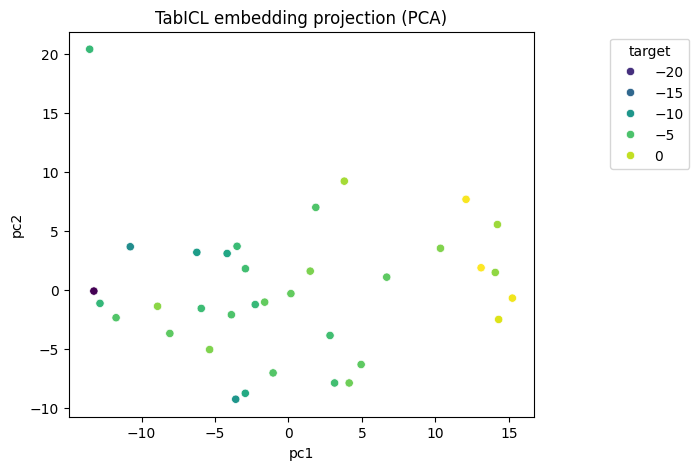

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_train_emb)
pca_df = pd.DataFrame(pca_2d, columns=["pc1", "pc2"], index=X_train_reg.index)
pca_df["target"] = y_train_reg

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="target", palette="viridis", ax=ax)
ax.set_title("TabICL embedding projection (PCA)")
sns.move_legend(ax, loc="upper right", bbox_to_anchor=(1.35, 1.0))
plt.show()